# FMATCH 3/10 — Swath-product readers (CERES SSF, CLDPIX, VIIRS cloud)

**PR topic**: the three readers for *swath* datasets — data organized along a
satellite ground track rather than on a regular lat/lon grid — completing the
nine-reader registry started in the previous PR:

| reader key | dataset | native organization |
|---|---|---|
| `ssf` | [CERES SSF](https://ceres.larc.nasa.gov/data/) / [FLASHFlux](https://ceres.larc.nasa.gov/data/) TOA+surface fluxes & clouds | 1-D footprint list (~20 km) |
| `cldpix` | CERES CLDPIX imager cloud pixels | 2-D (scanline, pixel) swath |
| `viirs_cloud` | [VIIRS cloud properties](https://ladsweb.modaps.eosdis.nasa.gov/missions-and-measurements/products/CLDPROP_D3_VIIRS_NOAA20) (D3 daily grid) | gridded L3 |

**The key idea — rasterize to stay uniform**: SSF and CLDPIX are *point/swath* data,
but every consumer downstream (tile manager, PSF aggregation) speaks the
`GridTile` contract. So these readers parse the whole file once (cached on the
instance), then bin the points onto a regular sub-grid covering each requested 2°
tile using the shared `rasterize_points_to_grid` helper. Same interface, no special
cases downstream.

The same SSF reader serves both the standard SSF product and the RBSP **FLASHFlux**
stream (identical file format, lower latency) — FLASHFlux feeds FMATCH-IMAGER-FLASH.

In [1]:
import sys
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [2]:
import libera_utils.footprint_matching.readers  # noqa: F401  (import triggers registration)
from libera_utils.footprint_matching.readers.registry import ReaderRegistry
from libera_utils.footprint_matching.types import OperationalMode, TileKey

## 1. The registry is now complete: all nine readers

In [3]:
print(ReaderRegistry.list_readers())

['cldpix', 'era5', 'era5_pressure', 'igbp', 'nise', 'ssf', 'viirs_aod', 'viirs_brdf', 'viirs_cloud']


## 2. SSF: footprint point data → gridded tile

The fixture below writes a synthetic SSF file with the real product's structure:
a 1-D `Footprints` dimension, thematic groups (`Time_and_Position`, `Scene_Type`, …),
longitudes in the 0–360 convention, and the `LowerUpper` / `AeroTypePct` secondary
axes that the reader flattens into 1-D per-footprint variables. We scatter footprints
along a synthetic ground track crossing our tile, then ask for the tile.

In [4]:
from tests.test_data.footprint_matching.fixtures import (
    make_cldpix_fixture,
    make_ssf_fixture,
    make_viirs_cloud_d3_fixture,
)

workdir = Path(tempfile.mkdtemp(prefix="fmatch_nb03_"))
rng = np.random.default_rng(7)

n_fp = 400
track_lats = np.linspace(-1.0, 5.0, n_fp) + rng.normal(0, 0.35, n_fp)  # noisy ground track
track_lons = np.linspace(11.0, 15.0, n_fp) + rng.normal(0, 0.35, n_fp)
aod = 0.15 + 0.1 * np.sin(np.radians(track_lats * 60)) + rng.normal(0, 0.01, n_fp)

ssf_path = make_ssf_fixture(
    workdir,
    lats=track_lats,
    lons_0360=track_lons % 360.0,
    aerosol_optical_depth=aod,
    clear_coverage=rng.uniform(0, 100, n_fp),
    cloud_optical_depth_lower=rng.lognormal(1.0, 0.6, n_fp),
    cloud_water_particle_radius_lower=rng.uniform(5, 25, n_fp),
    cloud_ice_particle_radius_lower=rng.uniform(20, 60, n_fp),
    cloud_classification=rng.choice([1001, 1191, 1372], n_fp).astype(float),
    shortwave_adm_type=rng.integers(1, 30, n_fp).astype(float),
    longwave_adm_type=rng.integers(1, 30, n_fp).astype(float),
)
ssf_cls = ReaderRegistry.get("ssf")
ssf = ssf_cls(ssf_path)

tile = ssf.load_tile(TileKey("ssf", lat_idx=46, lon_idx=96))  # lat [2,4], lon [12,14]
print(f"tile source={tile.source}  data shape={tile.data.shape}  (variables, lat, lon)")

tile source=ssf  data shape=(33, 10, 10)  (variables, lat, lon)


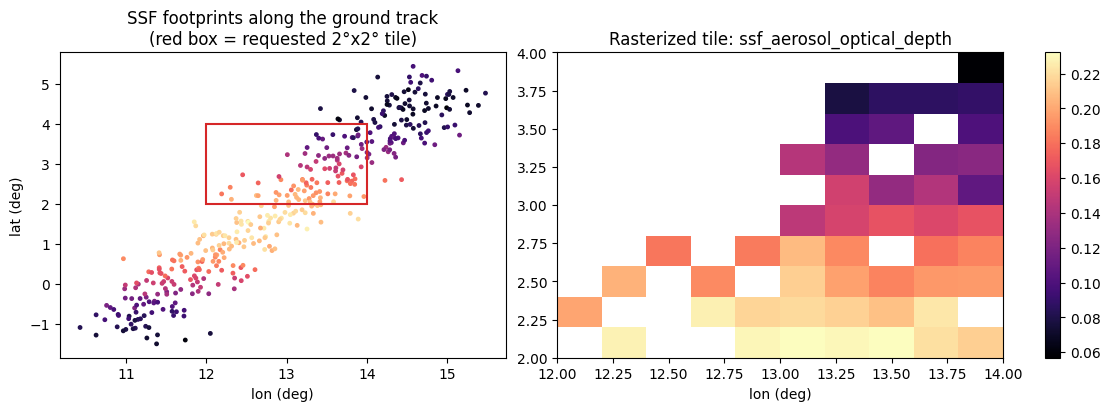

In [5]:
var_names = [v.name for v in ssf_cls.VARIABLES]
aod_idx = var_names.index("aerosol_optical_depth")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
ax1.scatter(track_lons, track_lats, c=aod, s=6, cmap="magma")
ax1.add_patch(plt.Rectangle((12, 2), 2, 2, fill=False, ec="tab:red", lw=1.5))
ax1.set_title("SSF footprints along the ground track\n(red box = requested 2°x2° tile)")
ax1.set_xlabel("lon (deg)")
ax1.set_ylabel("lat (deg)")

im = ax2.pcolormesh(tile.lons, tile.lats, tile.data[aod_idx], shading="auto", cmap="magma")
ax2.set_title("Rasterized tile: ssf_aerosol_optical_depth")
ax2.set_xlabel("lon (deg)")
fig.colorbar(im, ax=ax2)
plt.show()

Cells with no footprint stay NaN — coverage is preserved honestly and later feeds
the per-variable `*_coverage` accounting in the aggregation stage.

## 3. Mode gating: `only_modes`

SSF carries an extended IMAGER-only variable set (layered cloud fields, assimilated
aerosol properties, surface albedo, TOA incoming solar). Those `VariableSpec`s are
pinned with `only_modes=(IMAGER,)` so FMATCH-CAM products never see them while
FMATCH-IMAGER gets them automatically — one reader, mode-dependent contract.

In [6]:
from libera_utils.footprint_matching.types import spec_active_in_mode

for mode in (OperationalMode.CAM, OperationalMode.IMAGER):
    active = [v.name for v in ssf_cls.VARIABLES if spec_active_in_mode(v, mode)]
    print(f"{mode.name:6s}: {len(active):2d} SSF variables")
imager_only = [
    v.name
    for v in ssf_cls.VARIABLES
    if spec_active_in_mode(v, OperationalMode.IMAGER) and not spec_active_in_mode(v, OperationalMode.CAM)
]
print(f"IMAGER-only fields: {imager_only}")

CAM   :  0 SSF variables
IMAGER: 33 SSF variables
IMAGER-only fields: ['aerosol_optical_depth', 'clear_coverage', 'cloud_optical_depth_lower', 'cloud_water_particle_radius_lower', 'cloud_ice_particle_radius_lower', 'cloud_classification', 'shortwave_adm_type', 'longwave_adm_type', 'layer_coverage_lower', 'layer_coverage_upper', 'cloud_coverage_multilayer_lower', 'cloud_coverage_multilayer_upper', 'cloud_top_pressure_lower', 'cloud_top_pressure_upper', 'cloud_base_pressure_lower', 'cloud_base_pressure_upper', 'cloud_particle_phase_37um_lower', 'cloud_particle_phase_37um_upper', 'cloud_optical_depth_upper', 'cloud_water_particle_radius_upper', 'cloud_ice_particle_radius_upper', 'match_aot', 'aerosol_type_percentage_type0', 'aerosol_type_percentage_type1', 'aerosol_type_percentage_type2', 'aerosol_type_percentage_type3', 'aerosol_type_percentage_type4', 'aerosol_type_percentage_type5', 'aerosol_type_percentage_type6', 'imager_dark_target_land_055um_corrected_aerosol_optical_depth', 'image

## 4. CLDPIX: 2-D imager-pixel swath with colatitude/0–360 conventions

CLDPIX stores geolocation as [**colatitude**](https://en.wikipedia.org/wiki/Colatitude) (0° at the North Pole) and 0–360
longitude; the reader normalizes both. Same rasterization path as SSF.

In [7]:
# CLDPIX geolocation is 2-D (Scanlines, Pixels), like the real imager swath.
cld_lats = (np.repeat(np.linspace(1.0, 5.0, 40), 25) + rng.normal(0, 0.05, 1000)).reshape(40, 25)
cld_lons = (np.tile(np.linspace(12.2, 13.8, 25), 40) + rng.normal(0, 0.05, 1000)).reshape(40, 25)
cldpix_path = make_cldpix_fixture(workdir, lats=cld_lats, lons_0360=cld_lons % 360.0)
cldpix = ReaderRegistry.get("cldpix")(cldpix_path)
cld_tile = cldpix.load_tile(TileKey("cldpix", 46, 96))
print(f"cldpix tile shape={cld_tile.data.shape}; variables: {[v.name for v in type(cldpix).VARIABLES]}")

cldpix tile shape=(9, 40, 40); variables: ['cloud_optical_depth', 'cloud_water_path', 'cloud_effective_temperature', 'cloud_effective_height', 'cloud_effective_pressure', 'cloud_top_height', 'cloud_particle_radius', 'cloud_particle_phase', 'cloud_mask']


## 5. VIIRS cloud (D3 daily grid)

The VIIRS cloud reader consumes the gridded daily L3 product — included in this PR
because it belongs to the same cloud-property family the CAM pipeline consumes.

In [8]:
viirs_path = make_viirs_cloud_d3_fixture(
    workdir, n_lat=16, n_lon=16, lat_min=0.5, lat_max=7.5, lon_min=10.5, lon_max=17.5
)
viirs = ReaderRegistry.get("viirs_cloud")(viirs_path)
viirs_tile = viirs.load_tile(TileKey("viirs_cloud", 46, 96))
print(
    f"viirs_cloud tile shape={viirs_tile.data.shape}; cloud optical thickness mean={np.nanmean(viirs_tile.data[0]):.2f}"
)

viirs_cloud tile shape=(2, 4, 4); cloud optical thickness mean=4.00


## Where this goes next in the stack

With all nine readers registered, the **tile manager (next PR)** can map any
footprint `BoundingBox` to the set of `TileKey`s per ancillary source, cache the
loaded `GridTile`s, and hand them to PSF-weighted aggregation (two PRs out).